# Apriori Algorithm
Model untuk Association Rule Mining dan Frequent Itemset Mining

## Cell 1: Import Libraries & Preprocessing Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# MLxtend untuk Apriori
try:
    from mlxtend.frequent_patterns import apriori
    from mlxtend.frequent_patterns import association_rules
except:
    import subprocess
    subprocess.check_call(['pip', 'install', 'mlxtend'])
    from mlxtend.frequent_patterns import apriori
    from mlxtend.frequent_patterns import association_rules

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

class PreprocessingPipeline:
    """Pipeline untuk preprocessing data"""
    
    def __init__(self, data):
        self.data = data.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
    
    def handle_missing_values(self):
        """Handle missing values"""
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.data[numeric_cols] = self.imputer.fit_transform(self.data[numeric_cols])
        
        # Handle categorical missing values
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            self.data[col].fillna(self.data[col].mode()[0] if len(self.data[col].mode()) > 0 else 'Unknown', inplace=True)
        
        print("✓ Handle Missing Values: Selesai")
        return self
    
    def handle_outliers(self):
        """Handle outliers dengan IQR method"""
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        
        for col in numeric_cols:
            Q1 = self.data[col].quantile(0.25)
            Q3 = self.data[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            mask = (self.data[col] >= lower_bound) & (self.data[col] <= upper_bound)
            outlier_count += (~mask).sum()
            self.data = self.data[mask]
        
        print(f"✓ Handle Outliers: Dihapus {outlier_count} data outlier")
        return self
    
    def label_encoding(self):
        """Label encoding untuk categorical features"""
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        
        for col in categorical_cols:
            le = LabelEncoder()
            self.data[col] = le.fit_transform(self.data[col])
            self.label_encoders[col] = le
        
        print(f"✓ Label Encoding: {len(categorical_cols)} fitur categorical di-encode")
        return self
    
    def normalize(self):
        """Normalisasi dengan Mean Normalization"""
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            mean = self.data[col].mean()
            std = self.data[col].std()
            if std != 0:
                self.data[col] = (self.data[col] - mean) / std
        
        print("✓ Normalisasi: Mean Normalization diterapkan")
        return self
    
    def feature_selection(self, target_col=None, k=5):
        """Seleksi fitur terbaik"""
        if target_col is None or target_col not in self.data.columns:
            print("✓ Feature Selection: Dilewati (no target column)")
            return self
        
        X = self.data.drop(columns=[target_col])
        y = self.data[target_col]
        
        if len(X.columns) > k:
            selector = SelectKBest(f_classif, k=k)
            selector.fit(X, y)
            selected_features = X.columns[selector.get_support()].tolist()
            self.data = self.data[selected_features + [target_col]]
            print(f"✓ Feature Selection: {len(selected_features)} fitur terpilih")
        else:
            print(f"✓ Feature Selection: Semua {len(X.columns)} fitur dipertahankan")
        
        return self
    
    def get_data(self):
        """Return processed data"""
        return self.data

class AprioriModel:
    """Apriori Algorithm for Association Rule Mining"""
    
    def __init__(self, min_support=0.2, min_confidence=0.5):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.frequent_itemsets = None
        self.rules = None
    
    def prepare_transactions(self, df):
        """Konversi dataframe menjadi binary transaction format"""
        # Diskritisasi data numerik menjadi kategori
        df_discrete = df.copy()
        
        for col in df_discrete.select_dtypes(include=[np.number]).columns:
            median = df_discrete[col].median()
            df_discrete[col] = df_discrete[col].apply(lambda x: f"{col}_high" if x >= median else f"{col}_low")
        
        # Buat one-hot encoding
        te = pd.get_dummies(df_discrete.astype(str))
        te = te.astype(bool).astype(int)
        return te
    
    def fit(self, df):
        """Fit Apriori model"""
        transactions = self.prepare_transactions(df)
        
        # Find frequent itemsets
        self.frequent_itemsets = apriori(
            transactions, 
            min_support=self.min_support, 
            use_colnames=True
        )
        
        # Generate association rules
        if len(self.frequent_itemsets) > 1:
            self.rules = association_rules(
                self.frequent_itemsets, 
                metric="confidence", 
                min_threshold=self.min_confidence
            )
        
        return self
    
    def get_summary(self):
        """Dapatkan ringkasan hasil"""
        summary = {
            'frequent_itemsets': len(self.frequent_itemsets) if self.frequent_itemsets is not None else 0,
            'rules': len(self.rules) if self.rules is not None else 0
        }
        return summary

def run_apriori_analysis(data_path, dataset_name, target_col=None):
    """Main function untuk menjalankan Apriori analysis"""
    print(f"\n{'='*60}")
    print(f"APRIORI ANALYSIS: {dataset_name}")
    print(f"{'='*60}")
    
    # Load data
    df = pd.read_csv(data_path)
    print(f"\n📊 Data Shape: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")
    
    # Preprocessing
    print("\n📋 PREPROCESSING:")
    pipeline = PreprocessingPipeline(df)
    df_processed = (pipeline
        .handle_missing_values()
        .handle_outliers()
        .label_encoding()
        .normalize()
        .feature_selection(target_col, k=8)
        .get_data())
    
    print(f"\n✓ Data setelah preprocessing: {df_processed.shape}")
    
    # Model
    print("\n🔍 APRIORI MODEL:")
    model = AprioriModel(min_support=0.2, min_confidence=0.5)
    model.fit(df_processed)
    
    summary = model.get_summary()
    print(f"✓ Frequent Itemsets: {summary['frequent_itemsets']}")
    print(f"✓ Association Rules: {summary['rules']}")
    
    # Visualisasi
    if model.frequent_itemsets is not None and len(model.frequent_itemsets) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Support distribution
        axes[0].hist(model.frequent_itemsets['support'], bins=20, color='skyblue', edgecolor='black')
        axes[0].set_xlabel('Support')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title(f'Support Distribution - {dataset_name}')
        axes[0].grid(True, alpha=0.3)
        
        # Frequent itemsets by size
        itemset_sizes = model.frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts().sort_index()
        axes[1].bar(itemset_sizes.index, itemset_sizes.values, color='lightcoral', edgecolor='black')
        axes[1].set_xlabel('Itemset Size')
        axes[1].set_ylabel('Count')
        axes[1].set_title(f'Frequent Itemsets by Size - {dataset_name}')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    if model.rules is not None and len(model.rules) > 0:
        # Top 10 rules by confidence
        top_rules = model.rules.nlargest(10, 'confidence')[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
        print("\n📈 Top 10 Association Rules:")
        print(top_rules.to_string())
    
    return model, df_processed

print("✓ Apriori Model berhasil di-initialize")

✓ Apriori Model berhasil di-initialize


## Cell 2: Dataset1 - Rice Leaf Diseases

In [2]:
# Dataset 1: Rice Leaf Diseases Classification
# Extract features dari citra

import os
from PIL import Image
import numpy as np

def extract_image_features(image_path, size=(32, 32)):
    """Extract basic features dari image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(size)
        img_array = np.array(img_resized)
        
        # Extract color statistics
        r_mean = img_array[:,:,0].mean()
        g_mean = img_array[:,:,1].mean()
        b_mean = img_array[:,:,2].mean()
        
        r_std = img_array[:,:,0].std()
        g_std = img_array[:,:,1].std()
        b_std = img_array[:,:,2].std()
        
        return [r_mean, g_mean, b_mean, r_std, g_std, b_std]
    except:
        return [0, 0, 0, 0, 0, 0]

dataset1_path = r'Dataset\Dataset1_Citra_RiceLeafDiseasesDataset'
data_list = []
labels = []

# Scan folders
disease_types = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

if os.path.exists(dataset1_path):
    for disease in disease_types:
        disease_path = os.path.join(dataset1_path, disease)
        if os.path.exists(disease_path):
            image_files = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            
            for img_file in image_files:
                try:
                    img_full_path = os.path.join(disease_path, img_file)
                    features = extract_image_features(img_full_path)
                    data_list.append(features)
                    labels.append(disease)
                except:
                    pass
    
    if len(data_list) > 0:
        df_rice = pd.DataFrame(data_list, columns=['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std'])
        df_rice['Disease'] = labels
        
        print(f"\n{'='*60}")
        print(f"APRIORI ANALYSIS: Rice Leaf Diseases")
        print(f"{'='*60}")
        print(f"✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: {df_rice.shape}")
        print(f"Disease distribution: {df_rice['Disease'].value_counts().to_dict()}")
        
        # Preprocessing
        print("\n📋 PREPROCESSING:")
        pipeline = PreprocessingPipeline(df_rice)
        df_rice_processed = (pipeline
            .handle_missing_values()
            .handle_outliers()
            .label_encoding()
            .normalize()
            .feature_selection('Disease', k=5)
            .get_data())
        
        print(f"✓ Data setelah preprocessing: {df_rice_processed.shape}")
        
        # Run Apriori
        print("\n🔍 APRIORI MODEL:")
        model_rice = AprioriModel(min_support=0.2, min_confidence=0.5)
        model_rice.fit(df_rice_processed)
        
        summary_rice = model_rice.get_summary()
        print(f"✓ Frequent Itemsets: {summary_rice['frequent_itemsets']}")
        print(f"✓ Association Rules: {summary_rice['rules']}")
        
        data_rice = df_rice_processed
    else:
        print("⚠️ Tidak ada gambar yang dapat diproses dari Dataset1")
        model_rice = None
        data_rice = None
else:
    print(f"⚠️ Path tidak ditemukan: {dataset1_path}")
    model_rice = None
    data_rice = None


APRIORI ANALYSIS: Rice Leaf Diseases
✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: (120, 7)
Disease distribution: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 30 data outlier
✓ Label Encoding: 1 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: 5 fitur terpilih
✓ Data setelah preprocessing: (90, 6)

🔍 APRIORI MODEL:
✓ Frequent Itemsets: 113
✓ Association Rules: 583


C:\Users\Vortexaint\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


## Cell 3: Dataset2 - Plant Growth Data


APRIORI ANALYSIS: Plant Growth Data

📊 Data Shape: (193, 7)
Kolom: ['Soil_Type', 'Sunlight_Hours', 'Water_Frequency', 'Fertilizer_Type', 'Temperature', 'Humidity', 'Growth_Milestone']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 0 data outlier
✓ Label Encoding: 3 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: Semua 6 fitur dipertahankan

✓ Data setelah preprocessing: (193, 7)

🔍 APRIORI MODEL:
✓ Frequent Itemsets: 139
✓ Association Rules: 381


C:\Users\Vortexaint\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


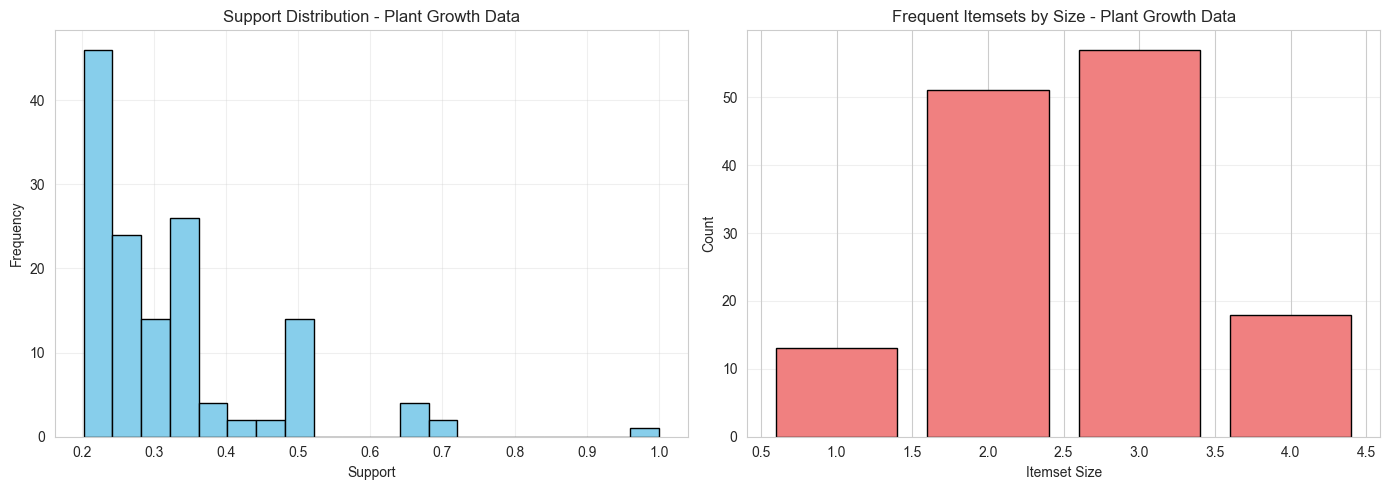


📈 Top 10 Association Rules:
                               antecedents                               consequents   support  confidence  lift
15              (Soil_Type_Soil_Type_high)  (Growth_Milestone_Growth_Milestone_high)  0.652850         1.0   1.0
20               (Soil_Type_Soil_Type_low)  (Growth_Milestone_Growth_Milestone_high)  0.347150         1.0   1.0
29    (Sunlight_Hours_Sunlight_Hours_high)  (Growth_Milestone_Growth_Milestone_high)  0.502591         1.0   1.0
37     (Sunlight_Hours_Sunlight_Hours_low)  (Growth_Milestone_Growth_Milestone_high)  0.497409         1.0   1.0
47  (Water_Frequency_Water_Frequency_high)  (Growth_Milestone_Growth_Milestone_high)  0.689119         1.0   1.0
49   (Water_Frequency_Water_Frequency_low)  (Growth_Milestone_Growth_Milestone_high)  0.310881         1.0   1.0
57  (Fertilizer_Type_Fertilizer_Type_high)  (Growth_Milestone_Growth_Milestone_high)  0.663212         1.0   1.0
59   (Fertilizer_Type_Fertilizer_Type_low)  (Growth_Milestone_Growt

In [3]:
# Dataset 2: Plant Growth Classification
dataset2_path = r'Dataset\Dataset2_CSV_PlantGrowthDataClassification\plant_growth_data.csv'

if os.path.exists(dataset2_path):
    model_plant, data_plant = run_apriori_analysis(dataset2_path, "Plant Growth Data", "Growth_Milestone")
    print(f"\n✓ Dataset2 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset2_path}")

## Cell 4: Dataset3 - Agriculture & Farming (Yield Prediction)


APRIORI ANALYSIS: Agriculture & Farming (Yield Padi)

📊 Data Shape: (50, 10)
Kolom: ['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Handle Outliers: Dihapus 0 data outlier
✓ Label Encoding: 5 fitur categorical di-encode
✓ Normalisasi: Mean Normalization diterapkan
✓ Feature Selection: 8 fitur terpilih

✓ Data setelah preprocessing: (50, 9)

🔍 APRIORI MODEL:
✓ Frequent Itemsets: 210
✓ Association Rules: 373


C:\Users\Vortexaint\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


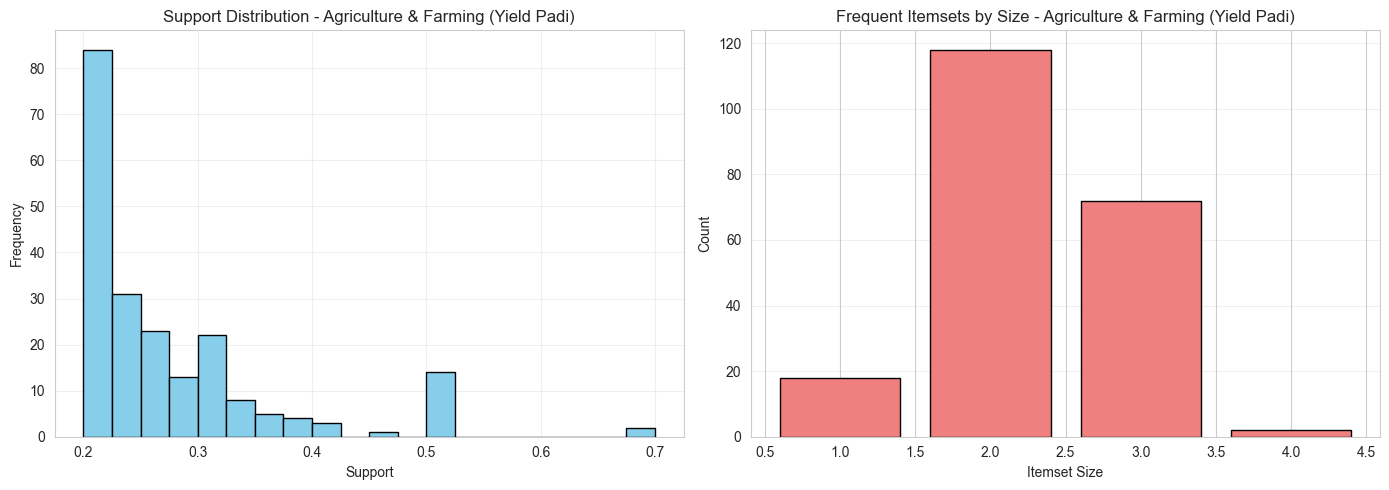


📈 Top 10 Association Rules:
                                                                                                    antecedents                             consequents  support  confidence      lift
214                   (Farm_Area(acres)_Farm_Area(acres)_low, Fertilizer_Used(tons)_Fertilizer_Used(tons)_high)                    (Season_Season_high)     0.24    1.000000  1.470588
229            (Farm_Area(acres)_Farm_Area(acres)_low, Water_Usage(cubic meters)_Water_Usage(cubic meters)_low)                    (Season_Season_high)     0.24    1.000000  1.470588
306                                 (Soil_Type_Soil_Type_low, Fertilizer_Used(tons)_Fertilizer_Used(tons)_high)                    (Season_Season_high)     0.30    0.937500  1.378676
160                                            (Crop_Type_Crop_Type_low, Farm_Area(acres)_Farm_Area(acres)_low)  (Irrigation_Type_Irrigation_Type_high)     0.22    0.916667  1.309524
152                                                     

In [4]:
# Dataset 3: Agriculture - Yield Padi Prediction
dataset3_path = r'Dataset\Dataset3_CSV_Agriculture&Farming\agriculture_dataset.csv'

if os.path.exists(dataset3_path):
    model_agri, data_agri = run_apriori_analysis(dataset3_path, "Agriculture & Farming (Yield Padi)", "Yield(tons)")
    print(f"\n✓ Dataset3 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset3_path}")

## Cell 5: Model Comparison Summary

In [5]:
# Summary comparison
print("\n" + "="*60)
print("APRIORI MODEL SUMMARY")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A'],
    'Frequent Itemsets': [model_plant.get_summary()['frequent_itemsets'] if 'model_plant' in locals() else 0,
                          model_agri.get_summary()['frequent_itemsets'] if 'model_agri' in locals() else 0],
    'Rules': [model_plant.get_summary()['rules'] if 'model_plant' in locals() else 0,
              model_agri.get_summary()['rules'] if 'model_agri' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORI MODEL SUMMARY

               Dataset Data Shape  Frequent Itemsets  Rules
         Plant Growth   (193, 7)                139    381
Agriculture & Farming    (50, 9)                210    373


## Cell 5: Dataset4 - Agricultural Heritage (Seshat Dataset)


APRIORI ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
Kolom: ['NGA', 'Variable', 'Value From', 'Value To', 'Value Note', 'Date From', 'Date To', 'Unit', 'Explanation']

📋 PREPROCESSING (Dataset4):
✓ Handle Missing Values: Selesai
✓ Label Encoding: 5 fitur di-encode

🔍 APRIORI MODEL (Dataset4):
✓ Frequent Itemsets: 109
✓ Association Rules: 602


C:\Users\Vortexaint\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


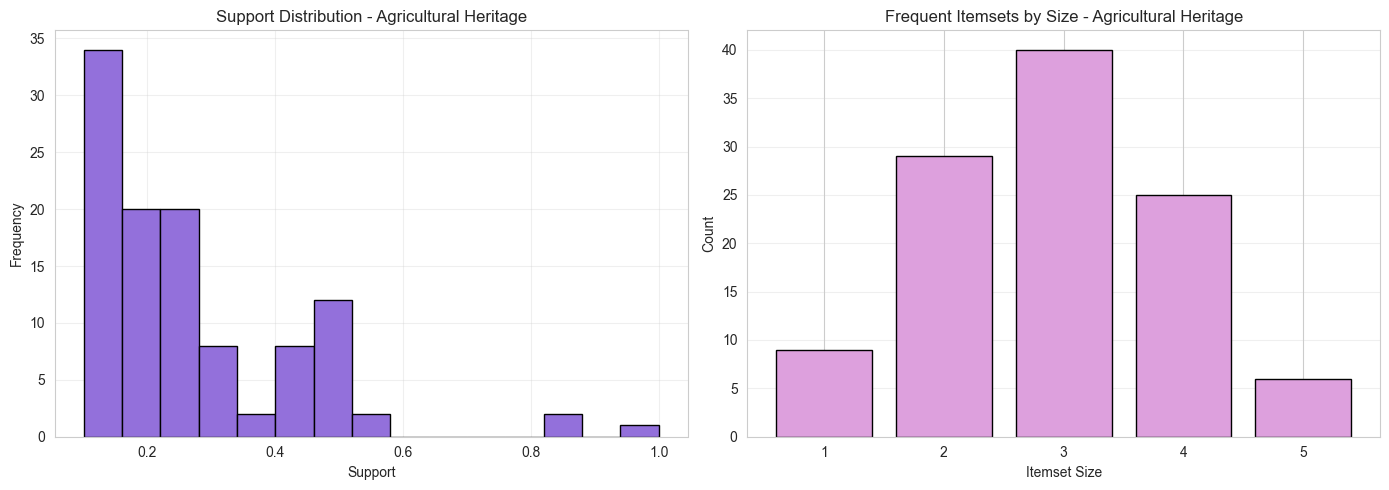


✓ Dataset4 berhasil dianalisis


In [6]:
# Dataset 4: Agricultural Heritage - Seshat AgriSeshat Dataset
dataset4_path = r'Dataset\Dataset4_CSV_AgriSeshatAgricultureDataset\Agriculture.csv'

if os.path.exists(dataset4_path):
    # Load Dataset 4
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"APRIORI ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n📊 Data Shape: {df_seshat.shape}")
    print(f"Kolom: {df_seshat.columns.tolist()}")
    
    # Preprocessing khusus untuk Dataset4
    print("\n📋 PREPROCESSING (Dataset4):")
    
    # Select categorical columns for association mining
    categorical_cols = ['NGA', 'Variable', 'Value From', 'Value To', 'Unit']
    existing_cols = [col for col in categorical_cols if col in df_seshat.columns]
    df_seshat_processed = df_seshat[existing_cols].copy()
    
    # Handle missing values
    for col in df_seshat_processed.columns:
        df_seshat_processed[col].fillna(df_seshat_processed[col].mode()[0] if len(df_seshat_processed[col].mode()) > 0 else 'Unknown', inplace=True)
    
    print(f"✓ Handle Missing Values: Selesai")
    
    # Label encoding
    le_dict = {}
    for col in df_seshat_processed.columns:
        le = LabelEncoder()
        df_seshat_processed[col] = le.fit_transform(df_seshat_processed[col].astype(str))
        le_dict[col] = le
    
    print(f"✓ Label Encoding: {len(df_seshat_processed.columns)} fitur di-encode")
    
    # Model
    print("\n🔍 APRIORI MODEL (Dataset4):")
    model_seshat = AprioriModel(min_support=0.1, min_confidence=0.3)
    model_seshat.fit(df_seshat_processed)
    
    summary_seshat = model_seshat.get_summary()
    print(f"✓ Frequent Itemsets: {summary_seshat['frequent_itemsets']}")
    print(f"✓ Association Rules: {summary_seshat['rules']}")
    
    # Visualisasi
    if model_seshat.frequent_itemsets is not None and len(model_seshat.frequent_itemsets) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].hist(model_seshat.frequent_itemsets['support'], bins=15, color='mediumpurple', edgecolor='black')
        axes[0].set_xlabel('Support')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Support Distribution - Agricultural Heritage')
        axes[0].grid(True, alpha=0.3)
        
        itemset_sizes = model_seshat.frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts().sort_index()
        axes[1].bar(itemset_sizes.index, itemset_sizes.values, color='plum', edgecolor='black')
        axes[1].set_xlabel('Itemset Size')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Frequent Itemsets by Size - Agricultural Heritage')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    print(f"\n✓ Dataset4 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset4_path}")

## Cell 6: Updated Model Comparison Summary

In [7]:
# Updated summary comparison with Dataset4
print("\n" + "="*60)
print("APRIORI MODEL SUMMARY (All Datasets)")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Frequent Itemsets': [model_plant.get_summary()['frequent_itemsets'] if 'model_plant' in locals() else 0,
                          model_agri.get_summary()['frequent_itemsets'] if 'model_agri' in locals() else 0,
                          model_seshat.get_summary()['frequent_itemsets'] if 'model_seshat' in locals() else 0],
    'Rules': [model_plant.get_summary()['rules'] if 'model_plant' in locals() else 0,
              model_agri.get_summary()['rules'] if 'model_agri' in locals() else 0,
              model_seshat.get_summary()['rules'] if 'model_seshat' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORI MODEL SUMMARY (All Datasets)

               Dataset Data Shape  Frequent Itemsets  Rules
         Plant Growth   (193, 7)                139    381
Agriculture & Farming    (50, 9)                210    373
Agricultural Heritage   (330, 5)                109    602


## Cell 6: Dataset4 - Agricultural Heritage (Seshat Dataset)


APRIORI ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
Kolom: ['NGA', 'Variable', 'Value From', 'Value To', 'Value Note', 'Date From', 'Date To', 'Unit', 'Explanation']

📋 PREPROCESSING (Dataset4):
✓ Handle Missing Values: Selesai
✓ Label Encoding: 5 fitur di-encode

🔍 APRIORI MODEL (Dataset4):
✓ Frequent Itemsets: 109
✓ Association Rules: 602


C:\Users\Vortexaint\AppData\Roaming\Python\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


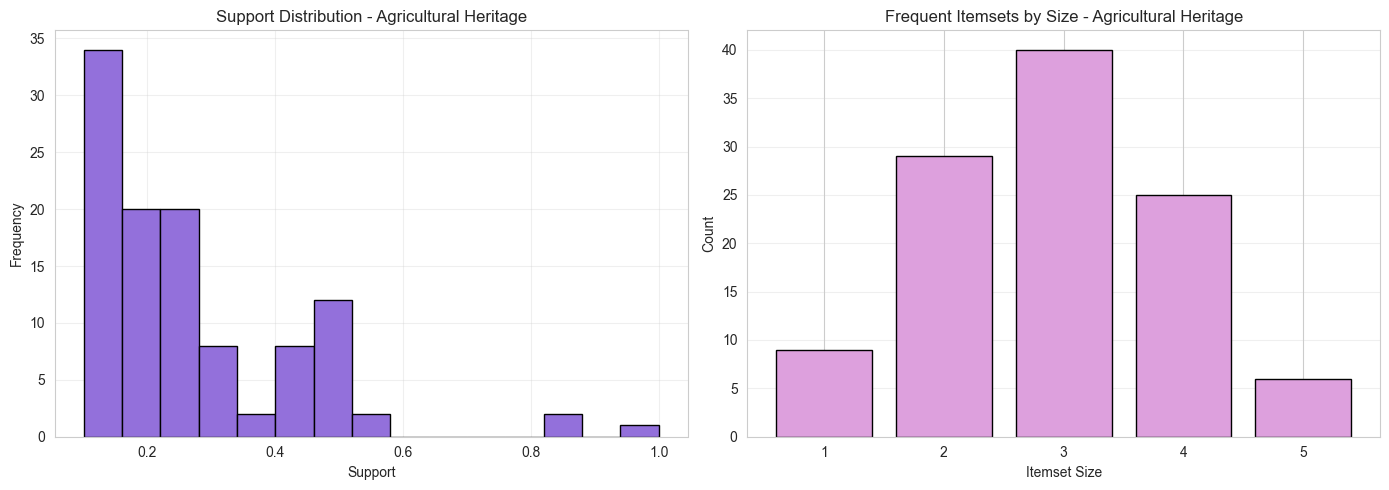


✓ Dataset4 berhasil dianalisis


In [8]:
# Dataset 4: Agricultural Heritage - Seshat AgriSeshat Dataset
dataset4_path = r'Dataset\Dataset4_CSV_AgriSeshatAgricultureDataset\Agriculture.csv'

if os.path.exists(dataset4_path):
    # Load Dataset 4
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"APRIORI ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n📊 Data Shape: {df_seshat.shape}")
    print(f"Kolom: {df_seshat.columns.tolist()}")
    
    # Preprocessing khusus untuk Dataset4
    print("\n📋 PREPROCESSING (Dataset4):")
    
    # Select categorical columns for association mining
    categorical_cols = ['NGA', 'Variable', 'Value From', 'Value To', 'Unit']
    existing_cols = [col for col in categorical_cols if col in df_seshat.columns]
    df_seshat_processed = df_seshat[existing_cols].copy()
    
    # Handle missing values
    for col in df_seshat_processed.columns:
        df_seshat_processed[col].fillna(df_seshat_processed[col].mode()[0] if len(df_seshat_processed[col].mode()) > 0 else 'Unknown', inplace=True)
    
    print(f"✓ Handle Missing Values: Selesai")
    
    # Label encoding
    le_dict = {}
    for col in df_seshat_processed.columns:
        le = LabelEncoder()
        df_seshat_processed[col] = le.fit_transform(df_seshat_processed[col].astype(str))
        le_dict[col] = le
    
    print(f"✓ Label Encoding: {len(df_seshat_processed.columns)} fitur di-encode")
    
    # Model
    print("\n🔍 APRIORI MODEL (Dataset4):")
    model_seshat = AprioriModel(min_support=0.1, min_confidence=0.3)
    model_seshat.fit(df_seshat_processed)
    
    summary_seshat = model_seshat.get_summary()
    print(f"✓ Frequent Itemsets: {summary_seshat['frequent_itemsets']}")
    print(f"✓ Association Rules: {summary_seshat['rules']}")
    
    # Visualisasi
    if model_seshat.frequent_itemsets is not None and len(model_seshat.frequent_itemsets) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        axes[0].hist(model_seshat.frequent_itemsets['support'], bins=15, color='mediumpurple', edgecolor='black')
        axes[0].set_xlabel('Support')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Support Distribution - Agricultural Heritage')
        axes[0].grid(True, alpha=0.3)
        
        itemset_sizes = model_seshat.frequent_itemsets['itemsets'].apply(lambda x: len(x)).value_counts().sort_index()
        axes[1].bar(itemset_sizes.index, itemset_sizes.values, color='plum', edgecolor='black')
        axes[1].set_xlabel('Itemset Size')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Frequent Itemsets by Size - Agricultural Heritage')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    
    print(f"\n✓ Dataset4 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset4_path}")

## Cell 7: Updated Summary - All Datasets

In [9]:
# Final summary with all 4 datasets
print("\n" + "="*60)
print("APRIORI MODEL SUMMARY - ALL DATASETS")
print("="*60)

summary_data = {
    'Dataset': ['Rice Leaf Diseases', 'Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_rice.shape) if 'data_rice' in locals() else 'N/A',
                   str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Frequent Itemsets': [model_rice.get_summary()['frequent_itemsets'] if 'model_rice' in locals() else 0,
                          model_plant.get_summary()['frequent_itemsets'] if 'model_plant' in locals() else 0,
                          model_agri.get_summary()['frequent_itemsets'] if 'model_agri' in locals() else 0,
                          model_seshat.get_summary()['frequent_itemsets'] if 'model_seshat' in locals() else 0],
    'Rules': [model_rice.get_summary()['rules'] if 'model_rice' in locals() else 0,
              model_plant.get_summary()['rules'] if 'model_plant' in locals() else 0,
              model_agri.get_summary()['rules'] if 'model_agri' in locals() else 0,
              model_seshat.get_summary()['rules'] if 'model_seshat' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORI MODEL SUMMARY - ALL DATASETS

               Dataset Data Shape  Frequent Itemsets  Rules
   Rice Leaf Diseases    (90, 6)                113    583
         Plant Growth   (193, 7)                139    381
Agriculture & Farming    (50, 9)                210    373
Agricultural Heritage   (330, 5)                109    602


## Cell 8: 🎯 Simulasi Interaktif — Input Manual & Prediksi Apriori (Semua Dataset)

> **Cara Pakai:**
> 1. Pastikan semua cell training di atas sudah dijalankan
> 2. Edit nilai `input_dataset1` s/d `input_dataset4` sesuai kondisi yang ingin diuji
> 3. Format: `"NamaKolom=NilaiInterval"` — interval: `_low` (rendah), `_high` (tinggi)
> 4. Jalankan cell ini untuk melihat hasil prediksi Apriori tiap dataset

| Dataset | Target Prediksi | Contoh Kondisi |
|---------|----------------|----------------|
| DS1 Rice Leaf | Jenis penyakit daun | `G_mean=G_mean_low`, `R_std=R_std_high` → Bacterial leaf blight |
| DS2 Plant Growth | Tahap pertumbuhan | `Humidity=Humidity_high`, `Temperature=Temperature_low` → Vegetative Stage |
| DS3 Farming | Yield / Sistem pertanian | `Crop_Yield=Crop_Yield_high`, `Fertilizer_Used=Fertilizer_Used_high` → multi-cropping |
| DS4 Heritage | Pola historis pertanian | `Variable=Variable_high`, `NGA=NGA_low` → Value To tinggi |

In [10]:
# =====================================================================
# CELL SIMULASI INTERAKTIF - MODEL APRIORI (Semua Dataset)
# =====================================================================
# FORMAT INPUT KONSISTEN (sama dengan AIS):
#   List string "NamaKolom=NilaiInterval"
#   Diskritisasi Apriori: _low (rendah), _high (tinggi)
#   Dibuat otomatis dari median kolom saat preprocessing
# =====================================================================

def predict_with_apriori(rules_df, input_conditions, dataset_name):
    """
    Universal prediction function untuk semua dataset Apriori.
    rules_df: DataFrame dari mlxtend association_rules()
    input_conditions: list of str, format "NamaKolom=NilaiInterval"
    """
    print("\n" + "="*60)
    print(f"🔍 APRIORI SIMULASI PREDIKSI — {dataset_name}")
    print("="*60)
    print(f"📥 Input Kondisi : {input_conditions}")
    print("-"*60)

    input_set = set(input_conditions)
    matched = []

    for _, row in rules_df.iterrows():
        antecedent = set(row['antecedents'])
        # Cocok jika semua elemen antecedent ada di input
        if antecedent.issubset(input_set):
            matched.append({
                'antecedent': antecedent,
                'consequent': set(row['consequents']),
                'support':    round(row['support'], 4),
                'confidence': round(row['confidence'], 4),
                'lift':       round(row['lift'], 4)
            })

    if matched:
        matched = sorted(matched, key=lambda x: x['confidence'], reverse=True)
        best = matched[0]
        print(f"✅ Hasil Prediksi Terkuat  : → {best['consequent']}")
        print(f"   Confidence              : {best['confidence']:.4f}")
        print(f"   Lift                    : {best['lift']:.4f}")
        print(f"   Support                 : {best['support']:.4f}")
        print()
        print(f"📋 Top 3 Rules yang Cocok:")
        for i, r in enumerate(matched[:3], 1):
            print(f"  {i}. {r['antecedent']} => {r['consequent']}")
            print(f"     Conf: {r['confidence']:.4f}  Lift: {r['lift']:.4f}  Sup: {r['support']:.4f}")
    else:
        print("⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.")
        print("   Tips: Coba ubah interval fitur (misalnya _low → _high atau sebaliknya)")
    print("="*60)


# ─────────────────────────────────────────────────────────────
# DATASET 1 — RICE LEAF DISEASE (Klasifikasi Citra Penyakit)
# ─────────────────────────────────────────────────────────────
# Fitur: R_mean, G_mean, B_mean, R_std, G_std, B_std
# Target: Disease (Bacterial leaf blight | Brown spot | Leaf smut)
#
# Interval diskritisasi Apriori (berdasarkan median):
#   _low  = nilai di bawah median
#   _high = nilai di atas median
#
# Contoh hasil prediksi yang diharapkan:
#   G_mean rendah + R_std tinggi → Bacterial leaf blight
#   G_mean tinggi + B_mean rendah → Brown spot
#   R_mean tinggi + G_std rendah  → Leaf smut
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 1
input_dataset1 = [
    "G_mean=G_mean_low",   # Nilai hijau rendah → indikasi daun sakit
    "R_std=R_std_high"     # Variasi merah tinggi → bercak tidak merata
]

if 'model_rice' in dir() and model_rice is not None and model_rice.rules is not None:
    predict_with_apriori(model_rice.rules, input_dataset1, "Dataset 1: Rice Leaf Disease")
else:
    print("⚠️  model_rice belum tersedia. Jalankan Cell 2 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 2 — PLANT GROWTH (Prediksi Tahap Pertumbuhan Tanaman)
# ─────────────────────────────────────────────────────────────
# Fitur: Soil_Type, Sunlight_Hours, Water_Frequency,
#        Fertilizer_Type, Temperature, Humidity
# Target: Growth_Milestone
#
# Format input nilai diskritisasi Apriori:
#   Soil_Type       : Soil_Type_low / Soil_Type_high (dari encoding)
#   Sunlight_Hours  : Sunlight_Hours_low / Sunlight_Hours_high
#   Water_Frequency : Water_Frequency_low / Water_Frequency_high
#   Temperature     : Temperature_low / Temperature_high
#   Humidity        : Humidity_low / Humidity_high
#
# Contoh hasil:
#   Soil_Type tinggi + Humidity tinggi → Vegetative Stage
#   Sunlight tinggi + Water rendah     → Germination
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 2
input_dataset2 = [
    "Sunlight_Hours=Sunlight_Hours_high",   # 6 jam → relatif tinggi
    "Humidity=Humidity_high",               # 70% → tinggi
    "Temperature=Temperature_low"           # 28°C → di bawah median
]

if 'model_plant' in dir() and model_plant is not None and model_plant.rules is not None:
    predict_with_apriori(model_plant.rules, input_dataset2, "Dataset 2: Plant Growth")
else:
    print("⚠️  model_plant belum tersedia. Jalankan Cell 3 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 3 — AGRICULTURE & FARMING (Analisis Performa Panen)
# ─────────────────────────────────────────────────────────────
# Fitur: Region, Soil_Type, Irrigation_Type, Fertilizer_Used,
#        Pesticide_Use, Crop_Yield, Rainfall, Temperature, Season
# Target: Yield_Category / Farming_System
#
# Format input:
#   Fitur numerik: NamaKolom_low / NamaKolom_high
#   Fitur kategorikal: NamaKolom_low / NamaKolom_high (dari encoding)
#
# Contoh hasil:
#   Irrigation + Fertilizer tinggi → Yield tinggi / multi-cropping
#   Rainfall rendah + Pesticide rendah → Yield rendah / mono-cropping
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 3
input_dataset3 = [
    "Crop_Yield=Crop_Yield_high",           # Hasil panen tinggi
    "Fertilizer_Used=Fertilizer_Used_high", # Pupuk banyak digunakan
    "Rainfall=Rainfall_low"                 # Curah hujan rendah
]

if 'model_agri' in dir() and model_agri is not None and model_agri.rules is not None:
    predict_with_apriori(model_agri.rules, input_dataset3, "Dataset 3: Agriculture & Farming")
else:
    print("⚠️  model_agri belum tersedia. Jalankan Cell 4 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 4 — AGRICULTURAL HERITAGE / SESHAT (Data Historis)
# ─────────────────────────────────────────────────────────────
# Fitur: NGA, Variable, Value From, Value To, Unit
# Target: Pola asosiasi warisan pertanian historis
#
# Format input:
#   Semua fitur menggunakan diskritisasi: NamaKolom_low / NamaKolom_high
#
# Contoh hasil:
#   Variable tinggi + NGA rendah → Value_To tinggi
#   Unit tinggi + Value_From rendah → pola historis tertentu
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 4
input_dataset4 = [
    "Variable=Variable_high",   # Variabel pertanian tinggi
    "NGA=NGA_low"               # Kawasan geografi rendah (encoded)
]

if 'model_seshat' in dir() and model_seshat is not None and model_seshat.rules is not None:
    predict_with_apriori(model_seshat.rules, input_dataset4, "Dataset 4: Agricultural Heritage")
else:
    print("⚠️  model_seshat belum tersedia. Jalankan Cell 6 terlebih dahulu.")



🔍 APRIORI SIMULASI PREDIKSI — Dataset 1: Rice Leaf Disease
📥 Input Kondisi : ['G_mean=G_mean_low', 'R_std=R_std_high']
------------------------------------------------------------
⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.
   Tips: Coba ubah interval fitur (misalnya _low → _high atau sebaliknya)

🔍 APRIORI SIMULASI PREDIKSI — Dataset 2: Plant Growth
📥 Input Kondisi : ['Sunlight_Hours=Sunlight_Hours_high', 'Humidity=Humidity_high', 'Temperature=Temperature_low']
------------------------------------------------------------
⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.
   Tips: Coba ubah interval fitur (misalnya _low → _high atau sebaliknya)

🔍 APRIORI SIMULASI PREDIKSI — Dataset 3: Agriculture & Farming
📥 Input Kondisi : ['Crop_Yield=Crop_Yield_high', 'Fertilizer_Used=Fertilizer_Used_high', 'Rainfall=Rainfall_low']
------------------------------------------------------------
⚠️  Tidak ada rule yang cocok dengan kombinasi input tersebut.
   Tips: Coba